## Standardization

In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [165]:
df = pd.read_csv('./data/data3.csv')

df.head()

,age,salary,purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


### Train Test Split

In [166]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
  df.drop('purchased', axis=1),
  df['purchased'],
  test_size=0.3,
  random_state=0
)

### StandardScaler

In [167]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit scaler to train set
scaler.fit(X_train)

# transform train and test set

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [168]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [169]:
X_train.describe().round(1)

,age,salary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [170]:
X_train_scaled.describe().round(1)

,age,salary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


### Scaling Effect

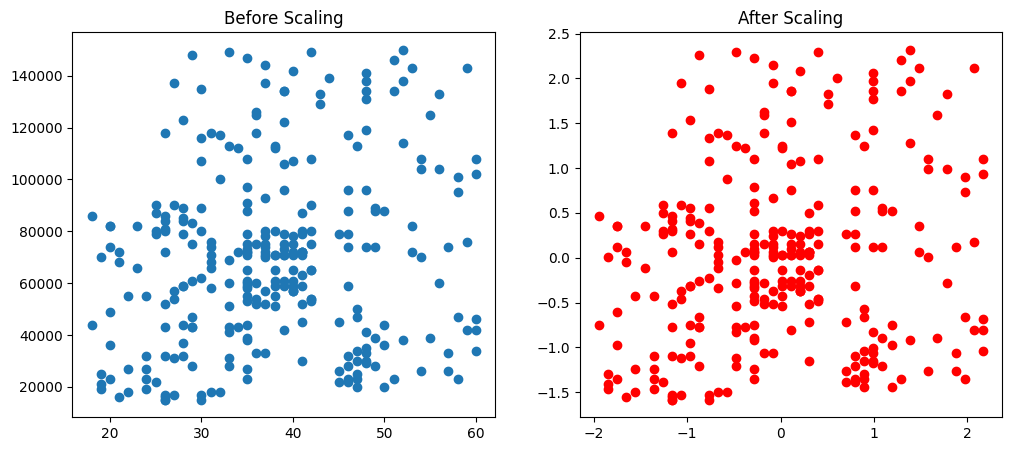

In [171]:
fig, axes = plt.subplots(1,2, figsize = (12, 5))

# Before Scaling
axes[0].scatter(X_train['age'],X_train['salary'])
axes[0].set_title("Before Scaling")

# After Scaling
axes[1].scatter(X_train_scaled['age'],X_train_scaled['salary'], color='red')
axes[1].set_title("After Scaling")

plt.show()

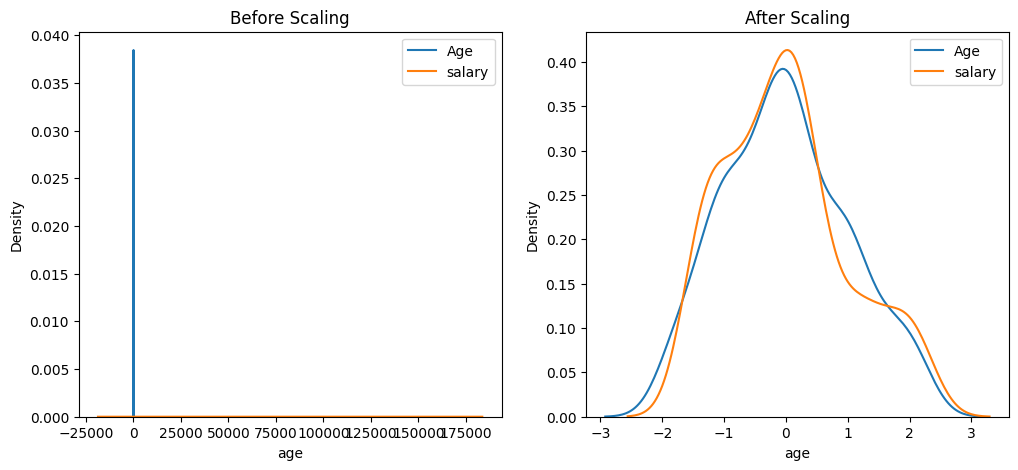

In [172]:
fig, axes = plt.subplots(1,2, figsize = (12, 5))

# Before Scaling
sns.kdeplot(X_train['age'], label='Age', ax = axes[0])
sns.kdeplot(X_train['salary'], label='salary', ax = axes[0])
axes[0].set_title("Before Scaling")
axes[0].legend()

# After Scaling
sns.kdeplot(X_train_scaled['age'], label='Age', ax = axes[1])
sns.kdeplot(X_train_scaled['salary'], label='salary', ax = axes[1])
axes[1].set_title("After Scaling")
axes[1].legend()

plt.show()

### Comparison of Distribution

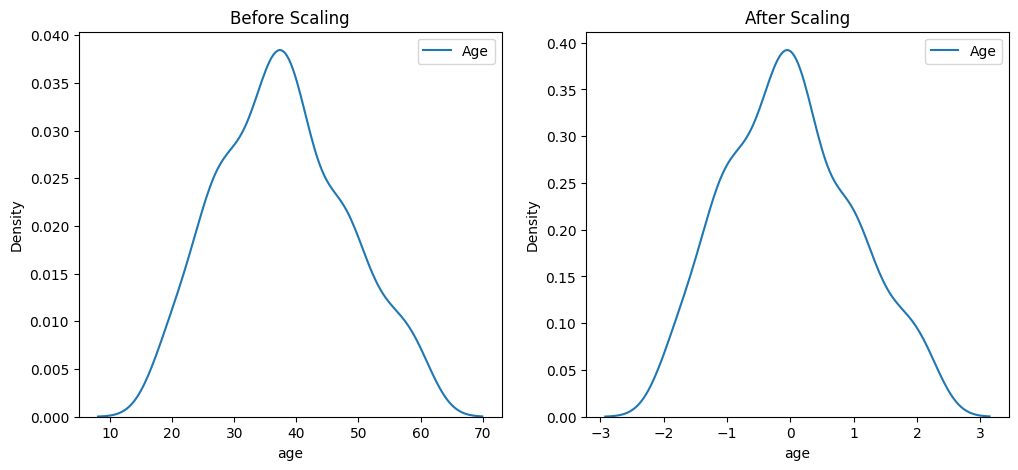

In [173]:
fig, axes = plt.subplots(1,2, figsize = (12, 5))

# Before Scaling
sns.kdeplot(X_train['age'], label='Age', ax = axes[0])
axes[0].set_title("Before Scaling")
axes[0].legend()

# After Scaling
sns.kdeplot(X_train_scaled['age'], label='Age', ax = axes[1])
axes[1].set_title("After Scaling")
axes[1].legend()

plt.show()

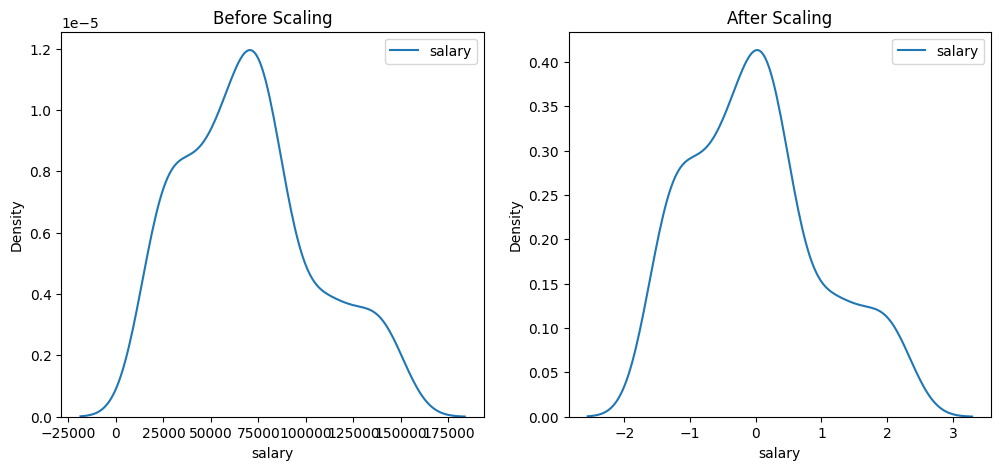

In [174]:
fig, axes = plt.subplots(1,2, figsize = (12, 5))

# Before Scaling
sns.kdeplot(X_train['salary'], label='salary', ax = axes[0])
axes[0].set_title("Before Scaling")
axes[0].legend()

# After Scaling
sns.kdeplot(X_train_scaled['salary'], label='salary', ax = axes[1])
axes[1].set_title("After Scaling")
axes[1].legend()

plt.show()

## Importance of scaling

In [175]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()
lr_scaled = LogisticRegression()

lr.fit(X_train, Y_train)
lr_scaled.fit(X_train_scaled, Y_train)

Y_pred = lr.predict(X_test)
Y_pred_scaled = lr_scaled.predict(X_test_scaled)

print(f"Actual : {accuracy_score(Y_test, Y_pred)}")
print(f"Scaled : {accuracy_score(Y_test, Y_pred_scaled)}")

Actual : 0.875
Scaled : 0.8666666666666667


In [176]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn_scaled = KNeighborsClassifier()

knn.fit(X_train, Y_train)
knn_scaled.fit(X_train_scaled, Y_train)

print("Actual:", accuracy_score(Y_test, knn.predict(X_test)))
print("Scaled:", accuracy_score(Y_test, knn_scaled.predict(X_test_scaled)))


Actual: 0.825
Scaled: 0.9166666666666666


## When to use Standardization

In [177]:
# use in following algorithms

# K-Means
# KNN
# PCA
# Artificial Neural network
# Gradient Descent

In [178]:
# When to now use (optional)

# Decision Trees
# Random Forest
# Gradient Boost
# XG Boost